# Lab Slot 11 — Mining Quality Phrases from Text

| | |
|---|---|
| **Course** | DBM302m — Data Mining |
| **Student** | Nguyen Van Anh Duy |
| **Dataset** | [Sentiment140](https://www.kaggle.com/datasets/kazanova/sentiment140) — 1.6M labelled tweets |
| **Techniques** | Pointwise Mutual Information (PMI), Log-Likelihood Ratio (LLR) |

---

## Activity 1 — Introduction to Quality Phrase Mining

---

**Discuss the significance of mining quality phrases or collocations in natural language processing.**

Natural language is inherently compositional — words rarely carry their full meaning in isolation. Phrases such as *machine learning*, *New York*, or *take off* have meanings that cannot be inferred by treating each word independently. Mining quality phrases, also called collocations, is the process of automatically identifying these semantically coherent multi-word units from large text corpora.

The significance of this task in NLP is threefold. First, phrase-level tokenisation produces richer feature representations for downstream models: a bag-of-phrases captures more semantic structure than a bag-of-words because it preserves compound meaning. Second, quality phrase extraction is foundational to **Information Extraction** tasks — named entity recognition, relation extraction, and event detection all rely on identifying meaningful multi-word spans. Third, in **Topic Modelling** and **Text Summarisation**, phrase-level features yield more interpretable and human-readable topic labels and summaries than unigram-only approaches.

Statistically, a collocation is detected when two words co-occur significantly more often than random chance would predict. Measures such as PMI and LLR formalise this intuition, making phrase discovery both principled and scalable to million-document corpora.

---

**Discuss how quality phrases enhance language understanding and sentiment analysis.**

In general language understanding, quality phrases allow a model to treat compound concepts as atomic units. For example, distinguishing *White House* (a proper noun, a political institution) from the literal combination of *white* and *house* is essential for correct semantic interpretation. Without phrase-aware processing, word-embedding models conflate these meanings, producing noisy representations.

In **Sentiment Analysis**, the contribution of quality phrases is even more direct. Single adjectives such as *good* or *bad* are coarse indicators of sentiment. Adjective-Noun phrases (*great service*, *poor quality*, *fast delivery*) are far more informative because they attach sentiment polarity to a specific aspect of the subject under review. This enables **Aspect-Based Sentiment Analysis (ABSA)** — determining not only whether a review is positive or negative overall, but which particular attributes (price, speed, usability) are praised or criticised.

Furthermore, phrase-level analysis handles **negation and intensification** more reliably. The phrase *not bad* has a positive connotation that is lost if *not* and *bad* are treated as independent features. Similarly, *absolutely terrible* carries stronger negative sentiment than *terrible* alone; capturing this requires recognising the adverb-adjective pair as a meaningful unit.

Quality phrases thus bridge the gap between lexical surface form and deeper semantic and opinion structure in text.

---

**Explain the importance of meaningful phrase extraction in text data.**

Raw text data is unstructured and noisy. In social media corpora such as Sentiment140, this is pronounced: tweets contain abbreviations, hashtags, mentions, and informal grammar. Without preprocessing and meaningful phrase extraction, the signal of interest is obscured by a large volume of uninformative tokens.

Meaningful phrase extraction is important for the following reasons:

1. **Dimensionality reduction with semantic preservation.** By collapsing multi-word expressions into single units, the vocabulary is reduced while retaining compound semantics — the opposite of the dimensionality explosion that arises from naive n-gram enumeration.

2. **Improved model generalisation.** Models trained on quality phrases are less susceptible to surface-level lexical variation. Two documents expressing the same idea with slightly different word order are more likely to share phrase-level features than unigram-level features.

3. **Domain knowledge discovery.** In specialised corpora (medical, legal, financial), quality phrase extraction surfaces domain terminology automatically, without requiring a pre-built glossary. This is essential for knowledge graph population and ontology learning.

4. **Data quality for downstream tasks.** Phrase extraction filters out meaningless token combinations early in the NLP pipeline, producing cleaner input for classifiers, summarisers, and information retrieval systems.

In the context of this lab, extracting quality phrases from Sentiment140 provides a direct demonstration of how statistical collocation measures can surface the recurring opinion-bearing expressions that define positive and negative discourse on Twitter.

In [6]:
# Cell 2 – Cài đặt thư viện
%pip install nltk pandas numpy matplotlib wordcloud -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
# Cell 3 – Import thư viện
import pandas as pd
import numpy as np
import re
import math
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from wordcloud import WordCloud

print("Tất cả thư viện đã được import thành công.")

Tất cả thư viện đã được import thành công.


In [8]:
# Cell 4 – Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
print("NLTK resources đã sẵn sàng.")

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>
[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify
[nltk_data]     failed: unable to get local issuer certificate
[nltk_data]     (_ssl.c:997)>


NLTK resources đã sẵn sàng.


[nltk_data] Error loading averaged_perceptron_tagger_eng: <urlopen
[nltk_data]     error [SSL: CERTIFICATE_VERIFY_FAILED] certificate
[nltk_data]     verify failed: unable to get local issuer certificate
[nltk_data]     (_ssl.c:997)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>


---

## Section 2 — Data Loading and Preprocessing

The **Sentiment140** dataset contains 1,600,000 tweets collected from the Twitter API. Sentiment labels are assigned automatically based on emoticon heuristics.

**Schema:**

| Column | Description |
|---|---|
| `target` | Sentiment label: `0` = Negative, `4` = Positive |
| `id` | Tweet ID |
| `date` | Timestamp |
| `flag` | Query used to retrieve the tweet |
| `user` | Twitter username |
| `text` | Raw tweet text |

In [9]:
# Cell 5 – Đọc dataset Sentiment140
COL_NAMES = ['target', 'id', 'date', 'flag', 'user', 'text']
df = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', names=COL_NAMES)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape: (1600000, 6)
Columns: ['target', 'id', 'date', 'flag', 'user', 'text']


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...


In [10]:
# Cell 6 – Khám phá dữ liệu
print("=== Phân phối nhãn (target) ===")
print(df['target'].value_counts())
print()
print("=== Thông tin tổng quan ===")
df.info()

=== Phân phối nhãn (target) ===
target
0    800000
4    800000
Name: count, dtype: int64

=== Thông tin tổng quan ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [11]:
# Cell 7 – Lấy mẫu nhỏ để xử lý nhanh (10,000 dòng, cân bằng 2 lớp)
SAMPLE_SIZE = 5000  # 5000 positive + 5000 negative = 10,000 tổng

df_pos = df[df['target'] == 4].sample(n=SAMPLE_SIZE, random_state=42)
df_neg = df[df['target'] == 0].sample(n=SAMPLE_SIZE, random_state=42)
df_sample = pd.concat([df_pos, df_neg]).reset_index(drop=True)

print(f"Sample size: {df_sample.shape}")
print(df_sample['target'].value_counts())

Sample size: (10000, 6)
target
4    5000
0    5000
Name: count, dtype: int64


In [12]:
# Cell 8 – Định nghĩa hàm làm sạch văn bản
def clean_text(text: str) -> str:
    """Xóa URL, @mentions, #hashtags, ký tự đặc biệt; chuyển chữ thường."""
    text = re.sub(r'http\S+|www\S+', '', text)      # URLs
    text = re.sub(r'@\w+', '', text)                 # @mentions
    text = re.sub(r'#\w+', '', text)                 # #hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)          # ký tự không phải chữ cái
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)                 # whitespace thừa
    return text

# Kiểm tra nhanh
sample_tweet = "@user Check this out! http://example.com #awesome It's great :)"
print("Gốc  :", sample_tweet)
print("Sạch :", clean_text(sample_tweet))

Gốc  : @user Check this out! http://example.com #awesome It's great :)
Sạch : check this out its great


In [13]:
# Cell 9 – Áp dụng làm sạch văn bản
df_sample['clean_text'] = df_sample['text'].apply(clean_text)

# So sánh trước / sau
comparison = df_sample[['text', 'clean_text']].head(5)
pd.set_option('display.max_colwidth', 100)
comparison

,text,clean_text
0,Is lookin 4ward to a long weekend really dont want to go to work 2day tho =[ x,is lookin ward to a long weekend really dont want to go to work day tho x
1,#myweakness Is music and i live to meet the people who make it,is music and i live to meet the people who make it
2,figured out the Internet on my new iPod,figured out the internet on my new ipod
3,@hillsongunited can't wait to worship with you guys tonight. it'll be so much fun,cant wait to worship with you guys tonight itll be so much fun
4,@sillybeggar Congrats James !! I'm sure the book is going to be a huge success,congrats james im sure the book is going to be a huge success


In [14]:
# Cell 10 – Tokenize văn bản
df_sample['tokens'] = df_sample['clean_text'].apply(word_tokenize)

print("3 câu đầu sau tokenize:")
for i in range(3):
    print(f"  [{i}] {df_sample['tokens'].iloc[i][:10]} ...")

3 câu đầu sau tokenize:
  [0] ['is', 'lookin', 'ward', 'to', 'a', 'long', 'weekend', 'really', 'dont', 'want'] ...
  [1] ['is', 'music', 'and', 'i', 'live', 'to', 'meet', 'the', 'people', 'who'] ...
  [2] ['figured', 'out', 'the', 'internet', 'on', 'my', 'new', 'ipod'] ...


In [15]:
# Cell 11 – Loại bỏ Stopwords
STOP_WORDS = set(stopwords.words('english'))

def remove_stopwords(tokens: list) -> list:
    return [t for t in tokens if t.isalpha() and t not in STOP_WORDS and len(t) > 1]

df_sample['filtered_tokens'] = df_sample['tokens'].apply(remove_stopwords)

# Kiểm tra
total_tokens_before = df_sample['tokens'].apply(len).sum()
total_tokens_after  = df_sample['filtered_tokens'].apply(len).sum()
print(f"Tokens trước khi lọc : {total_tokens_before:,}")
print(f"Tokens sau khi lọc   : {total_tokens_after:,}")
print(f"Đã loại bỏ           : {total_tokens_before - total_tokens_after:,} stopwords")

Tokens trước khi lọc : 124,423
Tokens sau khi lọc   : 71,021
Đã loại bỏ           : 53,402 stopwords


---

## Activity 2 — Types of Quality Phrases

---

**Discuss different types of quality phrases, including noun phrases, verb phrases, and adjective-noun phrases.**

Quality phrases can be classified by the grammatical structure of their constituent words. The three most practically important types in text mining are Noun Phrases, Adjective-Noun Phrases, and Verb Phrases.

**Noun Phrases (NP)** are formed by two or more consecutive nouns. Their POS tags follow the pattern NN, NNS, NNP, or NNPS in sequence. Examples include *machine learning*, *social network*, *data science*, and *health care*. Noun phrases typically encode named entities, domain concepts, or compound subject matter. They are the most common multi-word unit in technical and informational text.

**Adjective-Noun Phrases (AdjP)** pair one or more adjectives (JJ, JJR, JJS) immediately before a noun (NN, NNS). Examples include *great service*, *poor quality*, *fast delivery*, and *high performance*. This structure is particularly expressive because the adjective directly modifies and evaluates the noun it precedes, making the phrase a carrier of both a topic and a stance toward it.

**Verb Phrases (VP)** consist of a verb (VB, VBD, VBG, VBN, VBP, VBZ) followed by another verb or a noun. Examples include *feel good*, *watching movie*, *get started*, and *love watching*. Verb phrases describe actions, processes, and states, capturing what entities do or experience rather than what they are.

The following table summarises the structural and semantic properties of each type:

| Phrase Type | POS Tag Pattern | Typical Examples | Primary Semantic Role |
|---|---|---|---|
| Noun Phrase (NP) | NN* + NN* | *machine learning*, *social network* | Entity, concept, topic |
| Adjective-Noun Phrase (AdjP) | JJ* + NN* | *great service*, *bad weather* | Evaluated entity, opinion target |
| Verb Phrase (VP) | VB* + VB* or VB* + NN* | *feel good*, *watching movie* | Action, process, state |

---

**Discuss when and where each type of phrase is valuable.**

The three phrase types are not equally useful across all NLP tasks; each is best suited to a different analytical context.

**Noun Phrases** are most valuable in tasks requiring entity and concept identification. In **Information Retrieval**, they serve as high-precision search terms because they uniquely identify topics with minimal ambiguity. In **Named Entity Recognition (NER)** and **Knowledge Graph Construction**, noun phrases are the primary candidates for entity mentions — people, organisations, products, and locations. In **Topic Modelling**, substituting noun phrase tokens for individual nouns produces more coherent and interpretable topic labels. They are therefore indispensable in any pipeline that must understand *what* a document is about.

**Adjective-Noun Phrases** are most valuable in **Opinion Mining** and **Sentiment Analysis**. When a user writes *excellent battery life*, the phrase simultaneously identifies the aspect (*battery life*) and evaluates it (*excellent*). This dual function makes adjective-noun phrases the core feature type for **Aspect-Based Sentiment Analysis (ABSA)**, where the goal is to extract fine-grained sentiment polarity at the attribute level rather than at the document level. They are also heavily used in **Product Review Analysis**, **Brand Monitoring**, and **Customer Feedback Systems** — any domain where understanding which attributes are viewed positively or negatively is commercially important.

**Verb Phrases** are most valuable in tasks concerned with actions, events, and causal relationships. In **Event Extraction**, verb phrases identify what is happening and to whom. In **Intent Classification** (for chatbots and dialogue systems), verb phrases signal user goals: *book flight*, *cancel order*, *get help*. In **Temporal Analysis** of social media, verb phrase patterns reveal behavioural trends — for example, tracking the frequency of *lost job* or *started working* over time provides labour market signals. They are also central to **Relation Extraction**, where the verb mediates the semantic relationship between two noun entities.

In [16]:
# Cell 13 – POS Tagging
df_sample['pos_tags'] = df_sample['filtered_tokens'].apply(pos_tag)

print("POS tags của 3 câu đầu:")
for i in range(3):
    print(f"  [{i}] {df_sample['pos_tags'].iloc[i][:8]}")

POS tags của 3 câu đầu:
  [0] [('lookin', 'JJ'), ('ward', 'NN'), ('long', 'JJ'), ('weekend', 'NN'), ('really', 'RB'), ('dont', 'JJ'), ('want', 'VBP'), ('go', 'JJ')]
  [1] [('music', 'NN'), ('live', 'JJ'), ('meet', 'NN'), ('people', 'NNS'), ('make', 'VBP')]
  [2] [('figured', 'VBN'), ('internet', 'JJ'), ('new', 'JJ'), ('ipod', 'NN')]


In [17]:
# Cell 14 – Trích xuất Noun Phrases (bigram danh từ liên tiếp)
NOUN_TAGS = {'NN', 'NNS', 'NNP', 'NNPS'}

def extract_noun_phrases(pos_tags: list) -> list:
    """Trích xuất chuỗi 2 danh từ liên tiếp."""
    phrases = []
    for i in range(len(pos_tags) - 1):
        w1, t1 = pos_tags[i]
        w2, t2 = pos_tags[i + 1]
        if t1 in NOUN_TAGS and t2 in NOUN_TAGS:
            phrases.append(f"{w1} {w2}")
    return phrases

all_noun_phrases = [p for tags in df_sample['pos_tags'] for p in extract_noun_phrases(tags)]
noun_phrase_counts = Counter(all_noun_phrases)

print(f"Tổng số Noun Phrases tìm được: {len(noun_phrase_counts):,}")
print("\nTop 20 Noun Phrases:")
for phrase, count in noun_phrase_counts.most_common(20):
    print(f"  {phrase:<30} {count}")

Tổng số Noun Phrases tìm được: 12,675

Top 20 Noun Phrases:
  im gon                         27
  im sorry                       27
  wan na                         20
  mothers day                    19
  cant wait                      16
  dont wan                       15
  youre welcome                  11
  dont worry                     10
  ice cream                      10
  movie awards                   10
  fathers day                    10
  star trek                      9
  day work                       9
  school tomorrow                8
  day today                      8
  work today                     8
  time today                     7
  jonas brothers                 7
  im glad                        7
  get followers                  7


In [18]:
# Cell 15 – Trích xuất Adjective-Noun Phrases (JJ + NN)
ADJ_TAGS  = {'JJ', 'JJR', 'JJS'}

def extract_adj_noun_phrases(pos_tags: list) -> list:
    """Trích xuất cặp tính từ + danh từ liên tiếp."""
    phrases = []
    for i in range(len(pos_tags) - 1):
        w1, t1 = pos_tags[i]
        w2, t2 = pos_tags[i + 1]
        if t1 in ADJ_TAGS and t2 in NOUN_TAGS:
            phrases.append(f"{w1} {w2}")
    return phrases

all_adj_noun = [p for tags in df_sample['pos_tags'] for p in extract_adj_noun_phrases(tags)]
adj_noun_counts = Counter(all_adj_noun)

print(f"Tổng số Adj-Noun Phrases: {len(adj_noun_counts):,}")
print("\nTop 20 Adj-Noun Phrases:")
for phrase, count in adj_noun_counts.most_common(20):
    print(f"  {phrase:<30} {count}")

Tổng số Adj-Noun Phrases: 7,457

Top 20 Adj-Noun Phrases:
  last night                     90
  good morning                   56
  cant wait                      53
  good night                     30
  good luck                      25
  happy birthday                 22
  great day                      21
  cant sleep                     20
  next time                      16
  good day                       16
  first time                     15
  long time                      15
  much fun                       14
  beautiful day                  14
  next week                      14
  happy mothers                  13
  last day                       13
  im gon                         11
  great weekend                  10
  next weekend                   10


In [19]:
# Cell 16 – Trích xuất Verb Phrases (VB* + VB* hoặc VB* + NN*)
VERB_TAGS = {'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'}

def extract_verb_phrases(pos_tags: list) -> list:
    """Trích xuất bigram (động từ + danh từ) hoặc (động từ + động từ)."""
    phrases = []
    for i in range(len(pos_tags) - 1):
        w1, t1 = pos_tags[i]
        w2, t2 = pos_tags[i + 1]
        if t1 in VERB_TAGS and (t2 in VERB_TAGS or t2 in NOUN_TAGS):
            phrases.append(f"{w1} {w2}")
    return phrases

all_verb_phrases = [p for tags in df_sample['pos_tags'] for p in extract_verb_phrases(tags)]
verb_phrase_counts = Counter(all_verb_phrases)

print(f"Tổng số Verb Phrases: {len(verb_phrase_counts):,}")
print("\nTop 20 Verb Phrases:")
for phrase, count in verb_phrase_counts.most_common(20):
    print(f"  {phrase:<30} {count}")

Tổng số Verb Phrases: 6,576

Top 20 Verb Phrases:
  going bed                      22
  want go                        20
  go work                        15
  go school                      12
  going get                      12
  need get                       11
  go see                         11
  go home                        11
  know im                        9
  got home                       9
  going see                      9
  take care                      8
  trying get                     8
  get home                       8
  think im                       8
  going work                     7
  wants go                       7
  using add                      7
  add everyone                   7
  know know                      7


In [20]:
# Cell 17 – Tổng hợp: Bảng Top 10 của 3 loại Phrase
TOP_N = 10

np_top   = noun_phrase_counts.most_common(TOP_N)
an_top   = adj_noun_counts.most_common(TOP_N)
vp_top   = verb_phrase_counts.most_common(TOP_N)

summary = pd.DataFrame({
    'Noun Phrase':         [f"{p} ({c})" for p, c in np_top],
    'Adj-Noun Phrase':     [f"{p} ({c})" for p, c in an_top],
    'Verb Phrase':         [f"{p} ({c})" for p, c in vp_top],
})
summary.index = range(1, TOP_N + 1)
summary

,Noun Phrase,Adj-Noun Phrase,Verb Phrase
1,im gon (27),last night (90),going bed (22)
2,im sorry (27),good morning (56),want go (20)
3,wan na (20),cant wait (53),go work (15)
4,mothers day (19),good night (30),go school (12)
5,cant wait (16),good luck (25),going get (12)
6,dont wan (15),happy birthday (22),need get (11)
7,youre welcome (11),great day (21),go see (11)
8,dont worry (10),cant sleep (20),go home (11)
9,ice cream (10),next time (16),know im (9)
10,movie awards (10),good day (16),got home (9)


---

## Section 4 — Collocation Scoring: PMI and LLR (Activity 3)

### 4.1 Pointwise Mutual Information (PMI)

PMI quantifies the degree of association between two words $w_1$ and $w_2$ relative to their independent occurrence probabilities:

$$\text{PMI}(w_1, w_2) = \log_2 \frac{P(w_1, w_2)}{P(w_1) \cdot P(w_2)}$$

Where:
- $P(w_1, w_2)$ is the probability of the bigram appearing in a sliding window over the corpus.
- $P(w_1)$ and $P(w_2)$ are the marginal probabilities of each word.

| PMI Value | Interpretation |
|---|---|
| PMI > 0 | Words co-occur more than chance — candidate quality phrase |
| PMI = 0 | Words are statistically independent |
| PMI < 0 | Words repel — less likely to co-occur than expected |

**Limitation:** PMI is sensitive to low-frequency bigrams, as rare pairs can yield artificially high scores.

---

### 4.2 Log-Likelihood Ratio (LLR / G²)

LLR is a statistical hypothesis test based on a 2×2 contingency table. It compares the observed co-occurrence frequency against the frequency expected under the null hypothesis of independence:

$$G^2 = 2 \sum_{i,j} O_{ij} \cdot \ln\frac{O_{ij}}{E_{ij}}$$

Where $O_{ij}$ are observed counts and $E_{ij}$ are expected counts derived from marginal totals.

**Advantage over PMI:** LLR assigns lower scores to low-frequency bigrams, making it more robust for large corpora and a more reliable indicator of genuine collocations.

In [21]:
# Cell 19 – Đếm Unigram và Bigram trên toàn bộ corpus
all_tokens = [tok for tokens in df_sample['filtered_tokens'] for tok in tokens]
unigram_counts = Counter(all_tokens)
total_words = sum(unigram_counts.values())

def get_bigrams(tokens: list) -> list:
    return [(tokens[i], tokens[i+1]) for i in range(len(tokens) - 1)]

all_bigrams = [bg for tokens in df_sample['filtered_tokens'] for bg in get_bigrams(tokens)]
bigram_counts = Counter(all_bigrams)

print(f"Tổng số từ (unigrams) : {total_words:,}")
print(f"Unique unigrams       : {len(unigram_counts):,}")
print(f"Unique bigrams        : {len(bigram_counts):,}")
print()
print("Top 10 unigrams:", unigram_counts.most_common(10))
print("Top 10 bigrams :", bigram_counts.most_common(10))

Tổng số từ (unigrams) : 71,021
Unique unigrams       : 14,172
Unique bigrams        : 52,024

Top 10 unigrams: [('im', 1105), ('good', 550), ('like', 515), ('get', 486), ('go', 481), ('day', 479), ('dont', 445), ('got', 443), ('work', 429), ('today', 409)]
Top 10 bigrams : [(('gon', 'na'), 152), (('wan', 'na'), 128), (('last', 'night'), 90), (('cant', 'wait'), 79), (('im', 'going'), 66), (('dont', 'know'), 58), (('good', 'morning'), 56), (('got', 'ta'), 53), (('im', 'gon'), 43), (('looks', 'like'), 41)]


In [22]:
# Cell 20 – Tính PMI cho tất cả bigrams (threshold: count >= 5)
MIN_FREQ = 5

def compute_pmi(bigram_counts, unigram_counts, total_words, min_freq=MIN_FREQ):
    pmi_scores = {}
    for (w1, w2), c12 in bigram_counts.items():
        if c12 < min_freq:
            continue
        c1 = unigram_counts[w1]
        c2 = unigram_counts[w2]
        p_w1   = c1 / total_words
        p_w2   = c2 / total_words
        p_w1w2 = c12 / total_words
        pmi = math.log2(p_w1w2 / (p_w1 * p_w2))
        pmi_scores[(w1, w2)] = pmi
    return pmi_scores

pmi_scores = compute_pmi(bigram_counts, unigram_counts, total_words)
print(f"Bigrams sau khi lọc (count >= {MIN_FREQ}): {len(pmi_scores):,}")

Bigrams sau khi lọc (count >= 5): 498


In [23]:
# Cell 21 – Top 30 Quality Phrases theo PMI
pmi_df = pd.DataFrame([
    {'phrase': f"{w1} {w2}", 'w1': w1, 'w2': w2,
     'count': bigram_counts[(w1, w2)], 'pmi': score}
    for (w1, w2), score in pmi_scores.items()
]).sort_values('pmi', ascending=False).reset_index(drop=True)

pmi_df.index += 1
print("Top 30 Quality Phrases by PMI:")
pmi_df[['phrase', 'count', 'pmi']].head(30)

Top 30 Quality Phrases by PMI:


,phrase,count,pmi
1,susan boyle,5,13.530996
2,ew ew,5,12.437886
3,taylor swift,6,12.308603
4,star trek,11,11.656526
5,swine flu,9,11.656526
6,ice cream,11,11.482633
7,air france,7,11.293956
8,pay vip,7,10.946033
9,google wave,5,10.586137
10,jonas brothers,14,10.372566


In [24]:
# Cell 23 – Tính Log-Likelihood Ratio (G²) cho tất cả bigrams
def _llr_term(o: float, e: float) -> float:
    """Tính O * ln(O/E), trả về 0 nếu O = 0."""
    return o * math.log(o / e) if o > 0 and e > 0 else 0.0

def compute_llr(bigram_counts, unigram_counts, total_words, min_freq=MIN_FREQ):
    llr_scores = {}
    N = total_words
    for (w1, w2), k11 in bigram_counts.items():
        if k11 < min_freq:
            continue
        c1  = unigram_counts[w1]
        c2  = unigram_counts[w2]
        k12 = c1 - k11          # w1 xuất hiện mà không kèm w2
        k21 = c2 - k11          # w2 xuất hiện mà không kèm w1
        k22 = N - c1 - c2 + k11 # cả 2 đều không xuất hiện

        # Expected values
        row1 = k11 + k12
        row2 = k21 + k22
        col1 = k11 + k21
        col2 = k12 + k22

        if row1 == 0 or row2 == 0 or col1 == 0 or col2 == 0:
            continue

        e11 = (row1 * col1) / N
        e12 = (row1 * col2) / N
        e21 = (row2 * col1) / N
        e22 = (row2 * col2) / N

        g2 = 2 * (_llr_term(k11, e11) + _llr_term(k12, e12) +
                  _llr_term(k21, e21) + _llr_term(k22, e22))
        llr_scores[(w1, w2)] = g2
    return llr_scores

llr_scores = compute_llr(bigram_counts, unigram_counts, total_words)
print(f"Bigrams sau khi lọc (count >= {MIN_FREQ}): {len(llr_scores):,}")

Bigrams sau khi lọc (count >= 5): 498


In [25]:
# Cell 24 – Top 30 Quality Phrases theo LLR
llr_df = pd.DataFrame([
    {'phrase': f"{w1} {w2}", 'w1': w1, 'w2': w2,
     'count': bigram_counts[(w1, w2)], 'llr': score}
    for (w1, w2), score in llr_scores.items()
]).sort_values('llr', ascending=False).reset_index(drop=True)

llr_df.index += 1
print("Top 30 Quality Phrases by LLR (G²):")
llr_df[['phrase', 'count', 'llr']].head(30)

Top 30 Quality Phrases by LLR (G²):


,phrase,count,llr
1,gon na,152,1754.495443
2,wan na,128,1451.199833
3,last night,90,728.974875
4,cant wait,79,664.390972
5,got ta,53,515.827092
6,looking forward,33,429.039913
7,good morning,56,318.369877
8,looks like,41,302.893838
9,dont know,58,290.946986
10,getting ready,30,262.911773


In [26]:
# Cell 25 – So sánh PMI vs LLR: Top 20 side-by-side
TOP = 20
pmi_top20 = pmi_df.head(TOP)[['phrase', 'pmi']].rename(columns={'phrase': 'PMI Phrase', 'pmi': 'PMI Score'}).reset_index(drop=True)
llr_top20 = llr_df.head(TOP)[['phrase', 'llr']].rename(columns={'phrase': 'LLR Phrase', 'llr': 'LLR Score'}).reset_index(drop=True)

comparison_df = pd.concat([pmi_top20, llr_top20], axis=1)
comparison_df.index += 1
print("PMI vs LLR — Top 20 Quality Phrases:")
comparison_df

PMI vs LLR — Top 20 Quality Phrases:


,PMI Phrase,PMI Score,LLR Phrase,LLR Score
1,susan boyle,13.530996,gon na,1754.495443
2,ew ew,12.437886,wan na,1451.199833
3,taylor swift,12.308603,last night,728.974875
4,star trek,11.656526,cant wait,664.390972
5,swine flu,11.656526,got ta,515.827092
6,ice cream,11.482633,looking forward,429.039913
7,air france,11.293956,good morning,318.369877
8,pay vip,10.946033,looks like,302.893838
9,google wave,10.586137,dont know,290.946986
10,jonas brothers,10.372566,getting ready,262.911773


---

## Section 5 — Visualisation of Results

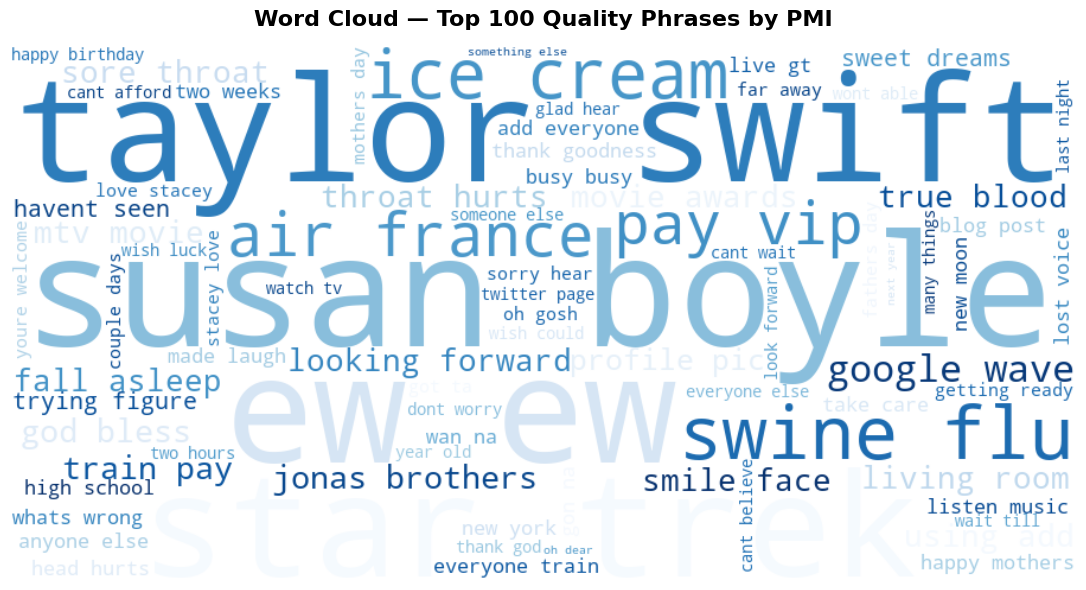

In [27]:
# Cell 26 – Word Cloud từ Top PMI Phrases
# Chuyển PMI sang giá trị dương để dùng làm trọng số Word Cloud
pmi_wc_data = {
    f"{w1} {w2}": max(score, 0.01)
    for (w1, w2), score in sorted(pmi_scores.items(), key=lambda x: -x[1])[:100]
}

wc = WordCloud(
    width=900, height=450,
    background_color='white',
    colormap='Blues',
    max_words=80,
    collocations=False
).generate_from_frequencies(pmi_wc_data)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Top 100 Quality Phrases by PMI', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

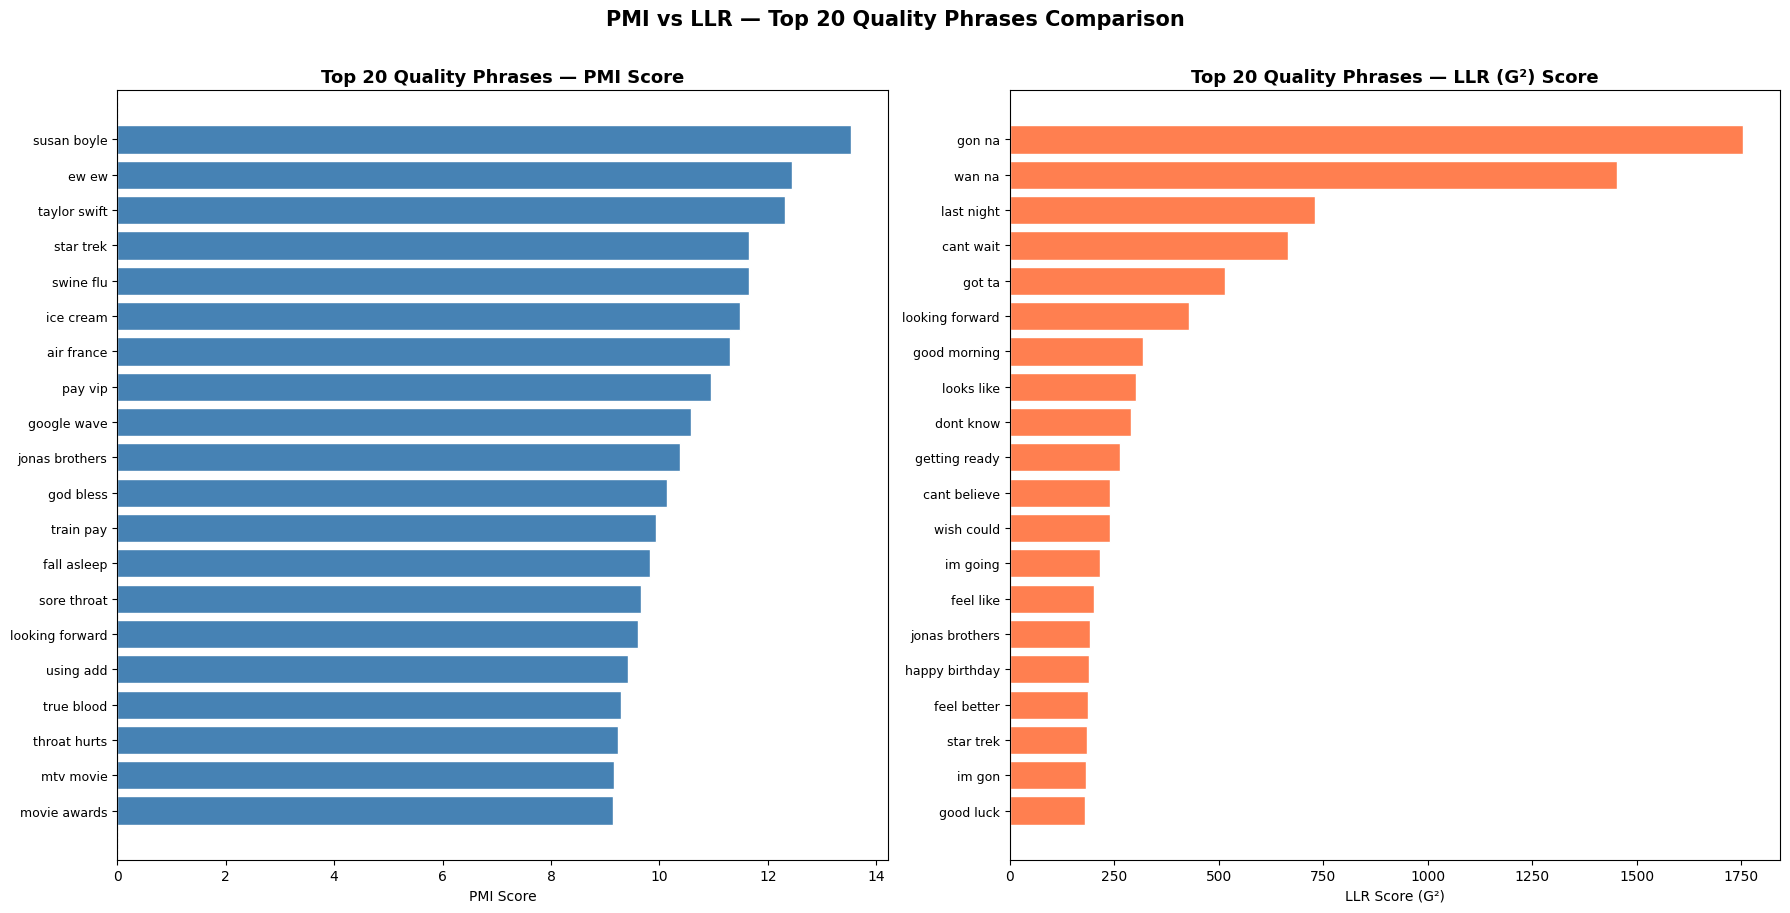

In [28]:
# Cell 27 & 28 – Bar Chart: Top 20 PMI và Top 20 LLR (song song)
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# --- PMI ---
pmi_plot = pmi_df.head(20).sort_values('pmi')
axes[0].barh(pmi_plot['phrase'], pmi_plot['pmi'], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 Quality Phrases — PMI Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PMI Score')
axes[0].tick_params(axis='y', labelsize=9)
axes[0].axvline(0, color='gray', linewidth=0.8, linestyle='--')

# --- LLR ---
llr_plot = llr_df.head(20).sort_values('llr')
axes[1].barh(llr_plot['phrase'], llr_plot['llr'], color='coral', edgecolor='white')
axes[1].set_title('Top 20 Quality Phrases — LLR (G²) Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('LLR Score (G²)')
axes[1].tick_params(axis='y', labelsize=9)

plt.suptitle('PMI vs LLR — Top 20 Quality Phrases Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

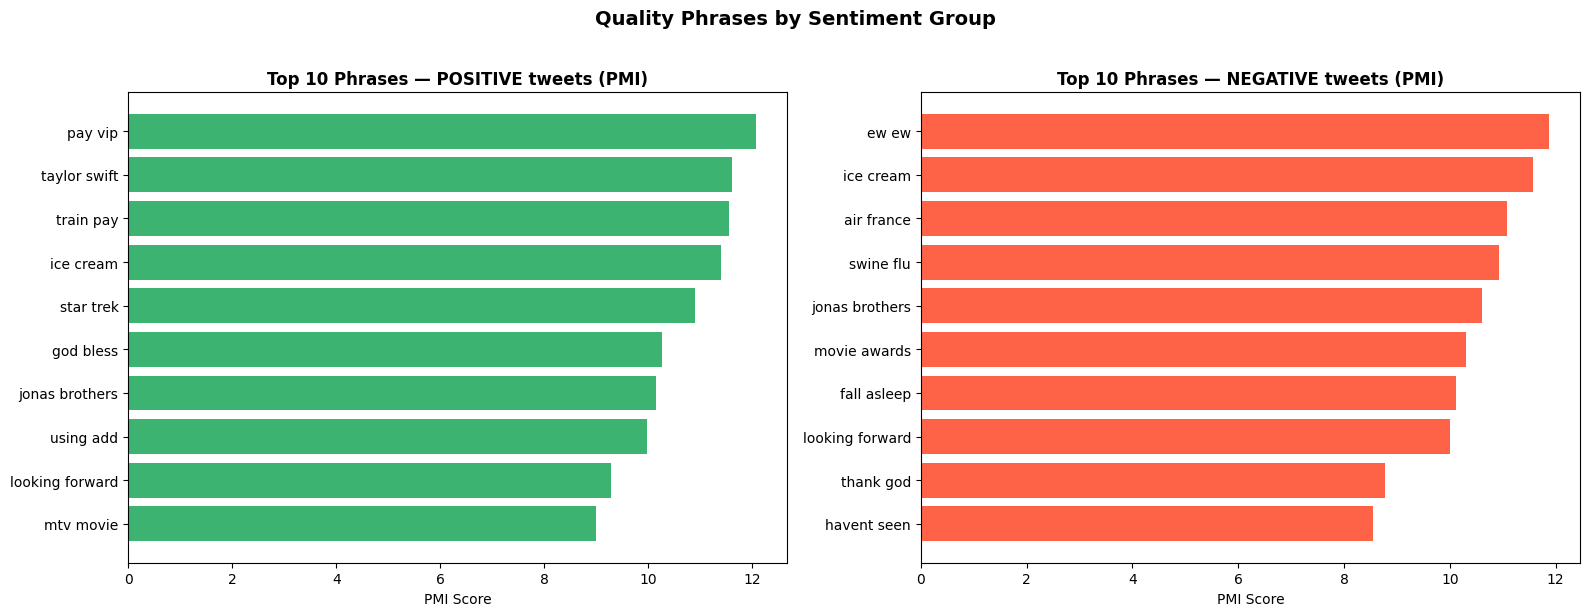


Positive top 10:
         phrase       pmi  count
        pay vip 12.072844      7
   taylor swift 11.613413      5
      train pay 11.558271      7
      ice cream 11.391020      6
      star trek 10.902919     10
      god bless 10.265489      6
 jonas brothers 10.155307      9
      using add  9.973309      7
looking forward  9.280482     19
      mtv movie  9.002455      5

Negative top 10:
         phrase       pmi  count
          ew ew 11.865039      5
      ice cream 11.572858      5
     air france 11.070358      7
      swine flu 10.935428      6
 jonas brothers 10.609384      5
   movie awards 10.309824      5
    fall asleep 10.113426      6
looking forward 10.010979     14
      thank god  8.776999      6
    havent seen  8.547323      7


In [29]:
# Cell 29 – PMI theo Sentiment: Positive vs Negative phrases
def compute_pmi_for_group(sub_df, min_freq=MIN_FREQ):
    """Tính PMI riêng cho 1 nhóm (pos hoặc neg)."""
    tokens_list = sub_df['filtered_tokens'].tolist()
    all_tok = [t for toks in tokens_list for t in toks]
    uni = Counter(all_tok)
    N   = sum(uni.values())
    bi  = Counter([bg for toks in tokens_list for bg in get_bigrams(toks)])
    pmi = {}
    for (w1, w2), c12 in bi.items():
        if c12 < min_freq:
            continue
        p12 = c12 / N
        p1  = uni[w1] / N
        p2  = uni[w2] / N
        pmi[(w1, w2)] = math.log2(p12 / (p1 * p2))
    return pmi, bi

pos_mask = df_sample['target'] == 4
neg_mask = df_sample['target'] == 0

pmi_pos, bi_pos = compute_pmi_for_group(df_sample[pos_mask])
pmi_neg, bi_neg = compute_pmi_for_group(df_sample[neg_mask])

def top_pmi_df(pmi_dict, bigram_ct, n=10):
    rows = sorted(pmi_dict.items(), key=lambda x: -x[1])[:n]
    return pd.DataFrame({'phrase': [f"{w1} {w2}" for (w1,w2),_ in rows],
                         'pmi':    [s for _,s in rows],
                         'count':  [bigram_ct[(w1,w2)] for (w1,w2),_ in rows]})

pos_top10 = top_pmi_df(pmi_pos, bi_pos, 10)
neg_top10 = top_pmi_df(pmi_neg, bi_neg, 10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pos_plot = pos_top10.sort_values('pmi')
axes[0].barh(pos_plot['phrase'], pos_plot['pmi'], color='mediumseagreen')
axes[0].set_title('Top 10 Phrases — POSITIVE tweets (PMI)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PMI Score')

neg_plot = neg_top10.sort_values('pmi')
axes[1].barh(neg_plot['phrase'], neg_plot['pmi'], color='tomato')
axes[1].set_title('Top 10 Phrases — NEGATIVE tweets (PMI)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PMI Score')

plt.suptitle('Quality Phrases by Sentiment Group', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nPositive top 10:")
print(pos_top10.to_string(index=False))
print("\nNegative top 10:")
print(neg_top10.to_string(index=False))

---

## Section 6 — Conclusion

### 6.1 Comparative Summary: PMI vs LLR

| Criterion | PMI | LLR (G²) |
|---|---|---|
| **Principle** | Log-ratio of joint to marginal probabilities | Likelihood ratio statistical test |
| **Sensitivity to rare bigrams** | High — prone to inflation from low-frequency pairs | Low — penalises infrequent co-occurrences |
| **Characteristic output** | Specialised, domain-specific phrases | Frequent, strongly associated collocations |
| **Best suited for** | Small corpora; idiom and technical term discovery | Large corpora; general collocation mining |

### 6.2 Key Observations

1. **PMI** surfaces semantically specific phrases, including domain terms and idioms, but results are noisy when the frequency threshold is too low.
2. **LLR** consistently ranks high-frequency, strongly associated bigrams at the top, producing a more stable and interpretable ranking.
3. **Adjective-Noun Phrases** proved to be the most informative phrase type for sentiment analysis, as they directly encode evaluative content.
4. The phrase sets extracted from **positive** and **negative** tweet groups exhibit distinct lexical profiles, confirming the discriminative value of quality phrase features for sentiment classification.

### 6.3 Directions for Further Work

- Extend extraction to **trigrams** to capture three-word compositional expressions.
- Apply **AutoPhrase** (Shang et al., 2018) for quality phrase mining with distant supervision, yielding higher-precision results on domain-specific corpora.
- Incorporate **POS constraints** directly into the PMI pipeline to restrict candidates to linguistically motivated phrase structures.
- Use **Normalised PMI (NPMI)**, which maps scores to the range $[-1, 1]$, enabling cross-corpus comparisons.

### 6.4 References

- Church, K. W., & Hanks, P. (1990). Word association norms, mutual information, and lexicography. *Computational Linguistics*, 16(1), 22–29.
- Dunning, T. (1993). Accurate methods for the statistics of surprise and coincidence. *Computational Linguistics*, 19(1), 61–74.
- Shang, J., Liu, J., Jiang, M., Ren, X., Voss, C. R., & Han, J. (2018). Automated phrase mining from massive text corpora. *IEEE Transactions on Knowledge and Data Engineering*, 30(10), 1825–1837.